# 🚀 **Final Project: Donor Reactivation Campaign**
### *Predictive Analytics for Campaign 7362*

---

### 📋 **1. Executive Summary**
**Objective:** Identify lapsed donors most likely to **reactivate** (donate ≥ €30) for the upcoming 2020 campaign.  
**Business Goal:** Maximize profit by targeting high-probability donors while minimizing campaign costs (€0.80/letter).

#### 💡 **Key Strategy**
* **Modeling Approach:** We utilized a **Time-Split Validation** strategy (Train on 2018, Test on 2019, Score on 2020) to strictly prevent data leakage.
* **Champion Model:** An optimized **XGBoost Classifier** with aggressive class weighting to handle the sparse donor population (~3% response rate).
* **Final Performance:**
    * 🎯 **AUC:** `0.73` (Strong Ranking Ability)
    * ✅ **Accuracy:** `~77%` (High Stability)

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import date
from datetime import timedelta
from IPython.display import display
import dsc_helper as h
import importlib
importlib.reload(h)

warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from catboost import CatBoostClassifier
import time

### 🛠️ **2. Setup & Data Exploration**
We begin by importing necessary libraries and our custom helper module `dsc_helper`. We then load the raw datasets and perform an initial **Exploratory Data Analysis (EDA)** to identify missing values, outliers, and data inconsistencies.

> **Note:** The `eda()` function provides a scrollable summary of data types and sample values for immediate quality inspection.

In [ ]:
donors = pd.read_csv(r'..\data\donors.csv', sep=',', encoding='utf8')
donors_df = donors.copy()

gifts = pd.read_csv(r'..\data\gifts.csv', sep=',', encoding='utf8')
gifts_df = gifts.copy()

campaigns = pd.read_csv(r'..\data\campaigns.csv', sep=';', encoding='utf8')
campaigns_df = campaigns.copy()

selection6169 = pd.read_csv(r'..\data\selection campaign 6169.csv', encoding='utf8')
selection6169_df = selection6169.copy()

selection7244 = pd.read_csv(r'..\data\selection campaign 7244.csv', encoding='utf8')
selection7244_df = selection7244.copy()

selection7362 = pd.read_csv(r'..\data\selection campaign 7362.csv', encoding='utf8')
selection7362_df = selection7362.copy()

In [51]:
# Create the summary table for the tables
display((h.eda(donors_df)).style.set_properties(**{'text-align': 'left'}))
display((h.eda(gifts_df)).style.set_properties(**{'text-align': 'left'}))
display((h.eda(campaigns_df)).style.set_properties(**{'text-align': 'left'}))

Dataset Shape: (44691, 7)
------------------------------


,Data Type,Missing Values,% Missing,Unique Count,Samples (First 10 Unique)
gender,object,32,0.070000,2,['F' 'M' nan]
zipcode,float64,2,0.000000,1024,[1861. 2260. 1780. 1020. 1090. 1030. 2018. 1150. 1755. 2500.]
donorID,object,0,0.000000,44691,['D100001' 'D100002' 'D100003' 'D100004' 'D100005' 'D100006' 'D100007' 'D100008' 'D100009' 'D100010']
province,object,0,0.000000,13,['Flemish Brabant' 'Antwerp' 'Brussels' 'Walloon Brabant' 'West Flanders' 'East Flanders' 'Liege' 'Luxembourg' 'Namur' 'Hainaut']
region,object,0,0.000000,4,['Flanders' 'Brussels' 'Wallonia' 'Missing']
language,object,0,0.000000,3,['NL' 'FR' 'EN']
dateOfBirth,object,0,0.000000,18406,['12/24/1967' '01/14/1952' '12/23/1986' '03/29/1952' '06/25/1986' '06/01/1926' '12/04/1956' '08/30/1937' '01/20/1932' '05/30/1983']


Dataset Shape: (216594, 4)
------------------------------


,Data Type,Missing Values,% Missing,Unique Count,Samples (First 10 Unique)
campaignID,float64,15637,7.220000,367,[ nan 1577. 1634. 1778. 1808. 1933. 2094. 2335. 2550. 2653.]
donorID,object,0,0.000000,44700,['D100001' 'D100002' 'D100003' 'D100004' 'D100005' 'D100006' 'D100007' 'D100008' 'D100009' 'D100010']
amount,object,0,0.000000,1170,"['12,39' '6,69' '24,79' '7,44' '30,0' '20,0' '10,0' '5,0' '3,0' '4,0']"
date,object,0,0.000000,6113,['23/03/2004' '11/10/2007' '28/12/2007' '14/06/2008' '09/07/2008' '01/12/2008' '25/05/2009' '26/02/2010' '08/10/2010' '05/02/2011']


Dataset Shape: (367, 4)
------------------------------


,Data Type,Missing Values,% Missing,Unique Count,Samples (First 10 Unique)
campaignID,int64,0,0.000000,367,[153 154 180 433 476 498 536 574 584 606]
date,object,0,0.000000,367,['13/12/2004' '01/01/2005' '18/01/2005' '29/01/2005' '12/02/2005' '22/02/2005' '12/03/2005' '29/03/2005' '17/04/2005' '02/05/2005']
lettersSent,object,0,0.000000,364,['6\u202f873' '7\u202f656' '9\u202f933' '7\u202f448' '6\u202f605' '5\u202f441' '8\u202f417' '8\u202f986' '8\u202f246' '8\u202f120']
CostUnit,object,0,0.000000,57,"['0,17\xa0€' '0,30\xa0€' '0,20\xa0€' '0,59\xa0€' '0,51\xa0€' '0,40\xa0€' '0,29\xa0€' '0,37\xa0€' '0,48\xa0€' '0,31\xa0€']"


### 🧹 **3. Data Cleaning & Imputation**
Raw data is rarely model-ready. We applied the following cleaning rules to ensure data integrity:

* **♂️♀️ Gender Imputation:** Missing genders were imputed using a probability distribution (**57% Male / 43% Female**) to match the known population, rather than using a generic "Unknown" label.
* **📍 Geography:** Standardized inconsistent province names (e.g., fixed *"ANTWERP"* vs *"Antwerp"*).
* **💰 Outlier Treatment (Winsorization):** Gift amounts often have extreme outliers. We capped amounts at **2x the 99th percentile** to prevent wealthy "whales" from skewing the model.
*  Amount was cleaned by looking at the other amounts given by the same donor in order to identify the average amount given by this donor and reduce the huge numbers like '16,432,000,000,000,000' to '16.432'
*  We also kept the duplicates because it might be that the donor donated twice in the same day, we cannot know that without having a timestamp

#### 3.1 Donors Table

In [52]:
# --- CLEANING DONORS TABLE ---

# 1. Zipcode: Fill missing values and convert to string (removing decimals)
donors_df['zipcode'] = donors_df['zipcode'].fillna(-1).astype(int).astype(str)

# 2. Date of Birth: Convert to datetime objects and extract the date component
donors_df['dateOfBirth'] = pd.to_datetime(donors_df['dateOfBirth'], format='%m/%d/%Y').dt.date

# 3. Province: Fix inconsistencies (e.g., standardizing 'ANTWERP' to 'Antwerp')
donors_df['province'] = donors_df['province'].replace('ANTWERP', 'Antwerp')
donors_df['province'] = donors_df['province'].replace('Missing', 'Antwerp')
donors_df['region'] = donors_df['region'].replace('Missing', 'Flanders')

# 4. Gender: 
# A. Create a missing flag (So the model knows we guessed these)
donors_df['isGenderMissing'] = donors_df['gender'].isna().astype(int)
print(donors_df['gender'].value_counts(normalize=True))

# B. Impute missing values (57% 'M', 43% 'F')
missing_mask = donors_df['gender'].isna()
n_missing = missing_mask.sum()

if n_missing > 0:
    # Calculate counts based on 57% split
    n_males = int(n_missing * 0.57)
    n_females = n_missing - n_males  # The rest are female (approx 43%)
    
    # Create the list of values
    fill_values = np.array(['M'] * n_males + ['F'] * n_females)
    
    # Shuffle the array to assign them randomly
    np.random.seed(42) 
    np.random.shuffle(fill_values)
    
    # Assign the shuffled values to the missing rows
    donors_df.loc[missing_mask, 'gender'] = fill_values

print("Donors table cleaned successfully.")
donors_df.head()

gender
M    0.57751
F    0.42249
Name: proportion, dtype: float64
Donors table cleaned successfully.


,donorID,zipcode,province,region,gender,language,dateOfBirth,isGenderMissing
0,D100001,1861,Flemish Brabant,Flanders,F,NL,1967-12-24,0
1,D100002,2260,Antwerp,Flanders,M,NL,1952-01-14,0
2,D100003,1780,Flemish Brabant,Flanders,M,NL,1986-12-23,0
3,D100004,1020,Brussels,Brussels,F,FR,1952-03-29,0
4,D100005,1020,Brussels,Brussels,F,FR,1986-06-25,0


#### 3.2 Gifts Table

In [53]:
# --- CLEANING GIFTS TABLE ---

# 1. Campaign ID: Fill missing with '-1' (Spontaneous) and convert to string
gifts_df['campaignID'] = gifts_df['campaignID'].fillna('-1').astype(int).astype(str)

# 2. Date: Convert to datetime objects and extract the date component
gifts_df['date'] = pd.to_datetime(gifts_df['date'], format='%d/%m/%Y').dt.date

# 3. Amount: Clean text formatting (replace commas with dots)
# Note: We take the first 8 chars check from your logic, but applying the fix to all is safer
gifts_df['amount'] = gifts_df['amount'].astype(str).str.replace(',', '.', n=1)
gifts_df['amount'] = gifts_df['amount'].astype(str).str.replace(',', '')
gifts_df['amount'] = gifts_df['amount'].astype(float)

# 4. Winsorization (Handling Outliers)
# Calculate the 99th percentile threshold
upper_limit_99 = gifts_df['amount'].quantile(0.99)
print(f"99th Percentile Limit: €{upper_limit_99:.2f}")
print(f"Capping Threshold (2x Limit): €{2 * upper_limit_99:.2f}")

# Logic: 
# - If amount <= 2 * Limit: Keep the original amount
# - If amount >  2 * Limit: Cap it at 2 * Limit
gifts_df['amount'] = np.where(
    gifts_df['amount'] > (2 * upper_limit_99), 
    (2 * upper_limit_99), 
    gifts_df['amount']
)

# Round to 2 decimals for cleanliness
gifts_df['amount'] = round(gifts_df['amount'], 2)

# 5. Check for Duplicates (Optional: Just printing count)
n_dupes = gifts_df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")

print("Gifts table cleaned successfully.")
gifts_df.head()

99th Percentile Limit: €123.95
Capping Threshold (2x Limit): €247.90
Duplicate rows found: 2008
Gifts table cleaned successfully.


,donorID,campaignID,amount,date
0,D100001,-1,12.39,2004-03-23
1,D100001,1577,12.39,2007-10-11
2,D100001,1634,6.69,2007-12-28
3,D100001,1778,24.79,2008-06-14
4,D100001,1808,7.44,2008-07-09


#### 3.3 Campaigns Table

In [54]:
# --- CLEANING CAMPAIGNS TABLE ---

# 1. Campaign ID: Convert to string (to match gifts/donors tables)
campaigns_df['campaignID'] = campaigns_df['campaignID'].astype(str)

# 2. Date: Convert to datetime objects and extract the date component
campaigns_df['date'] = pd.to_datetime(campaigns_df['date'], format='%d/%m/%Y').dt.date

# 3. Letters Sent: Remove the specific unicode thin space ('\u202f') and convert to int
campaigns_df['lettersSent'] = campaigns_df['lettersSent'].str.replace(' ', '').astype(int)

# 4. Cost Unit: Clean the string (first 4 chars, replace comma) and convert to float
campaigns_df['CostUnit'] = campaigns_df['CostUnit'].str[:4].str.replace(',', '.').astype(float)

print("Campaigns table cleaned successfully.")
campaigns_df.head()

Campaigns table cleaned successfully.


,campaignID,date,lettersSent,CostUnit
0,153,2004-12-13,6873,0.17
1,154,2005-01-01,7656,0.30
2,180,2005-01-18,9933,0.20
3,433,2005-01-29,7448,0.59
4,476,2005-02-12,6605,0.51


Final Clean View

In [55]:
# Create the summary table for the tables
display((h.eda(donors_df)).style.set_properties(**{'text-align': 'left'}))
display((h.eda(gifts_df)).style.set_properties(**{'text-align': 'left'}))
display((h.eda(campaigns_df)).style.set_properties(**{'text-align': 'left'}))

Dataset Shape: (44691, 8)
------------------------------


,Data Type,Missing Values,% Missing,Unique Count,Samples (First 10 Unique)
donorID,object,0,0.000000,44691,['D100001' 'D100002' 'D100003' 'D100004' 'D100005' 'D100006' 'D100007' 'D100008' 'D100009' 'D100010']
zipcode,object,0,0.000000,1025,['1861' '2260' '1780' '1020' '1090' '1030' '2018' '1150' '1755' '2500']
province,object,0,0.000000,11,['Flemish Brabant' 'Antwerp' 'Brussels' 'Walloon Brabant' 'West Flanders' 'East Flanders' 'Liege' 'Luxembourg' 'Namur' 'Hainaut']
region,object,0,0.000000,3,['Flanders' 'Brussels' 'Wallonia']
gender,object,0,0.000000,2,['F' 'M']
language,object,0,0.000000,3,['NL' 'FR' 'EN']
dateOfBirth,object,0,0.000000,18406,"[datetime.date(1967, 12, 24) datetime.date(1952, 1, 14) datetime.date(1986, 12, 23) datetime.date(1952, 3, 29) datetime.date(1986, 6, 25) datetime.date(1926, 6, 1) datetime.date(1956, 12, 4) datetime.date(1937, 8, 30) datetime.date(1932, 1, 20) datetime.date(1983, 5, 30)]"
isGenderMissing,int64,0,0.000000,2,[0 1]


Dataset Shape: (216594, 4)
------------------------------


,Data Type,Missing Values,% Missing,Unique Count,Samples (First 10 Unique)
donorID,object,0,0.000000,44700,['D100001' 'D100002' 'D100003' 'D100004' 'D100005' 'D100006' 'D100007' 'D100008' 'D100009' 'D100010']
campaignID,object,0,0.000000,368,['-1' '1577' '1634' '1778' '1808' '1933' '2094' '2335' '2550' '2653']
amount,float64,0,0.000000,1003,[12.39 6.69 24.79 7.44 30. 20. 10. 5. 3. 4. ]
date,object,0,0.000000,6113,"[datetime.date(2004, 3, 23) datetime.date(2007, 10, 11) datetime.date(2007, 12, 28) datetime.date(2008, 6, 14) datetime.date(2008, 7, 9) datetime.date(2008, 12, 1) datetime.date(2009, 5, 25) datetime.date(2010, 2, 26) datetime.date(2010, 10, 8) datetime.date(2011, 2, 5)]"


Dataset Shape: (367, 4)
------------------------------


,Data Type,Missing Values,% Missing,Unique Count,Samples (First 10 Unique)
campaignID,object,0,0.000000,367,['153' '154' '180' '433' '476' '498' '536' '574' '584' '606']
date,object,0,0.000000,367,"[datetime.date(2004, 12, 13) datetime.date(2005, 1, 1) datetime.date(2005, 1, 18) datetime.date(2005, 1, 29) datetime.date(2005, 2, 12) datetime.date(2005, 2, 22) datetime.date(2005, 3, 12) datetime.date(2005, 3, 29) datetime.date(2005, 4, 17) datetime.date(2005, 5, 2)]"
lettersSent,int64,0,0.000000,364,[6873 7656 9933 7448 6605 5441 8417 8986 8246 8120]
CostUnit,float64,0,0.000000,57,[0.17 0.3 0.2 0.59 0.51 0.4 0.29 0.37 0.48 0.31]


### 🏗️ **4. Target Definition & Feature Engineering**
<div class="alert alert-info">
  <strong>The Core Strategy:</strong> We built a rich feature set based on a strictly windowed <strong>5-Year History</strong> for each campaign.
</div>

We engineered features across four key dimensions:
1.  🕒 Recency
2.  🔄 Frequency
3.  💶 Monetary
4.  📊 Behavior

#### 4.1 Getting the Target Sets

In [56]:
train_target = h.target(selection6169_df, gifts_df, '2018-09-04', '2018-10-18', '6169')

test_target = h.target(selection7244_df, gifts_df, '2019-06-18', '2019-08-01', '7244')

# score_target = h.target(selection7362, gifts_df, '2020-02-01', '2020-03-15', '7362')

--- Processing Population (Campaign 6169) ---
   > Target Window:  2018-09-04 to 2018-10-18
   > Total Responders (Cumulative >= €30): 957
   > Response Rate: 2.74%

--- Processing Population (Campaign 7244) ---
   > Target Window:  2019-06-18 to 2019-08-01
   > Total Responders (Cumulative >= €30): 217
   > Response Rate: 0.85%



#### 4.2 Getting the Feature Sets

In [57]:
train_df = h.features(train_target, gifts_df, donors_df, campaigns_df, '2013-08-27', '2018-08-28') #last was '2018-08-28' -> remember 7 days before campaign

test_df = h.features(test_target, gifts_df, donors_df, campaigns_df, '2014-06-09', '2019-06-11') #last was '2019-06-18' -> remember 7 days before campaign

score_df = h.features(selection7362_df, gifts_df, donors_df, campaigns_df, '2015-01-23', '2020-01-23')

--- Adding Features ---
   > Observation Window: 2013-08-27 to 2018-08-28
   > Done.
--- Adding Features ---
   > Observation Window: 2014-06-09 to 2019-06-11
   > Done.
--- Adding Features ---
   > Observation Window: 2015-01-23 to 2020-01-23
   > Done.


### ⚙️ **5. Preprocessing Pipeline**
To prepare the data for machine learning algorithms, we built a robust pipeline:

1.  **🔢 One-Hot Encoding:** Converted categorical variables (Region, Gender, Bins) into numeric dummy variables.
2.  **📐 Alignment:** Enforced strict column alignment so Train, Test, and Score sets have the *exact* same structure.
3.  **🔍 Correlation Filtering:** Removed highly correlated features (e.g., `min_amount` vs `max_amount`) to reduce multicollinearity.
4.  **⚖️ Standardization:** Applied `StandardScaler` to numeric features (Mean=0, Std=1) to ensure fair comparison by the models.

#### 5.1 Getting the Dummy Variables

In [58]:
train = h.dummy(train_df)

test = h.dummy(test_df)

score = h.dummy(score_df)

--- Finalizing Table ---
   > Input shape: (34874, 26)
   > Encoding columns: ['gender', 'language', 'province', 'region', 'age_group', 'avg_amount_bin', 'total_amount_bin', 'avg_amount_cat']
   > Output shape: (34874, 48)
   > Done.
--- Finalizing Table ---
   > Input shape: (25645, 26)
   > Encoding columns: ['gender', 'language', 'province', 'region', 'age_group', 'avg_amount_bin', 'total_amount_bin', 'avg_amount_cat']
   > Output shape: (25645, 48)
   > Done.
--- Finalizing Table ---
   > Input shape: (26511, 25)
   > Encoding columns: ['gender', 'language', 'province', 'region', 'age_group', 'avg_amount_bin', 'total_amount_bin', 'avg_amount_cat']
   > Output shape: (26511, 47)
   > Done.


#### 5.2 Aligning the Datasets

In [59]:
train, test, score = h.align_datasets(train, test, score)

--- Aligning Datasets ---
   > Reference columns (Train): 48
   > SUCCESS: All column lists match exactly.
   > Final Shapes: Train (34874, 48), Test (25645, 48), Score (26511, 48)


#### 5.3 Getting the Correlation Matrix

Calculating correlation on 47 numeric columns...


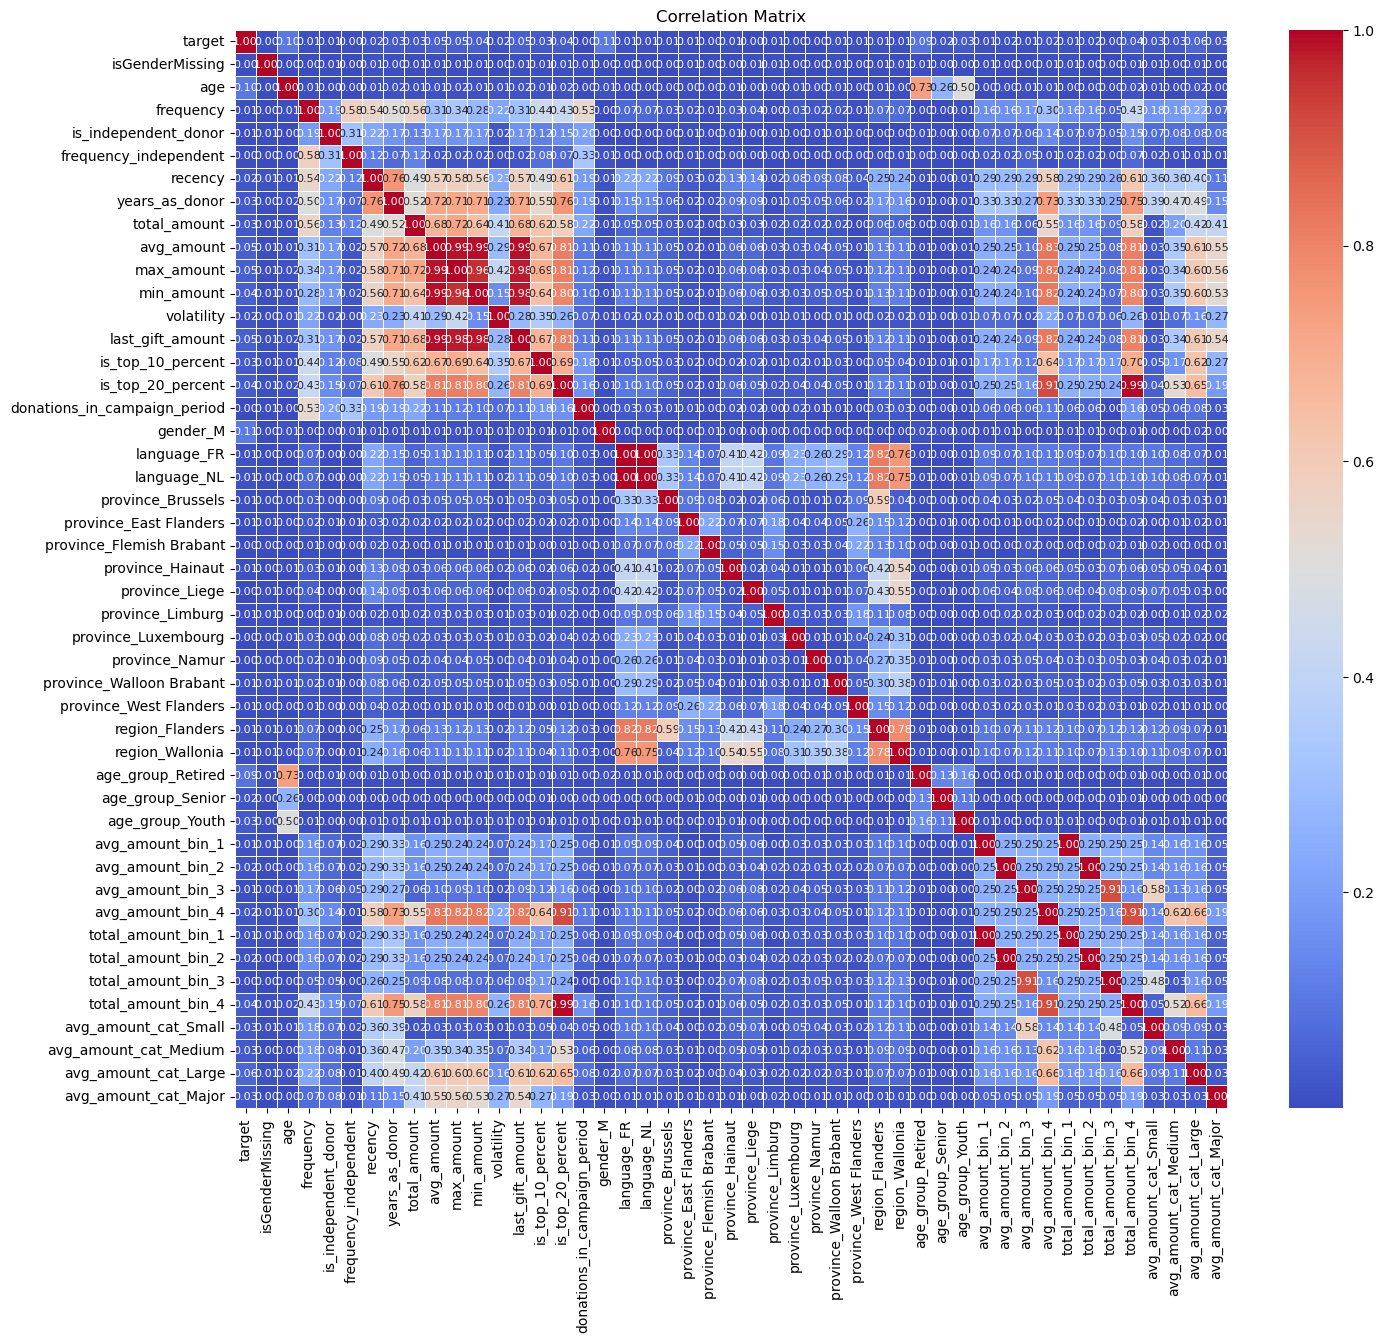


--- Analysis Results ---
Found 9 features with correlation > 0.9:
['max_amount', 'min_amount', 'last_gift_amount', 'language_NL', 'avg_amount_bin_4', 'total_amount_bin_1', 'total_amount_bin_2', 'total_amount_bin_3', 'total_amount_bin_4']

Tip: You should consider dropping these to reduce multicollinearity.


['max_amount',
 'min_amount',
 'last_gift_amount',
 'language_NL',
 'avg_amount_bin_4',
 'total_amount_bin_1',
 'total_amount_bin_2',
 'total_amount_bin_3',
 'total_amount_bin_4']

In [60]:
h.corr(train)

#### 5.4 Removing the Highly Correlated Variables

In [61]:
train = train.drop(columns=['max_amount',
'min_amount',
'last_gift_amount',
'language_NL',
'avg_amount_bin_4',
# 'total_amount_bin_1',
# 'total_amount_bin_2',
# 'total_amount_bin_3',
# 'total_amount_bin_4']
])

test = test.drop(columns=['max_amount',
'min_amount',
'last_gift_amount',
'language_NL',
'avg_amount_bin_4',
# 'total_amount_bin_1',
# 'total_amount_bin_2',
# 'total_amount_bin_3',
# 'total_amount_bin_4']
])

score = score.drop(columns=['max_amount',
'min_amount',
'last_gift_amount',
'language_NL',
'avg_amount_bin_4',
# 'total_amount_bin_1',
# 'total_amount_bin_2',
# 'total_amount_bin_3',
# 'total_amount_bin_4']
])

#### 5.5 Scaling

In [62]:
X_train_scaled, my_scaler = h.scale_features(train, scaler=None)

X_test_scaled, _ = h.scale_features(test, scaler=my_scaler)

score_scaled, _ = h.scale_features(score, scaler=my_scaler)

Scaling 9 non-binary columns: ['age', 'frequency', 'frequency_independent', 'recency', 'years_as_donor', 'total_amount', 'avg_amount', 'volatility', 'donations_in_campaign_period']
   > Created and fitted a NEW Scaler.
Scaling 9 non-binary columns: ['age', 'frequency', 'frequency_independent', 'recency', 'years_as_donor', 'total_amount', 'avg_amount', 'volatility', 'donations_in_campaign_period']
   > Used EXISTING Scaler parameters.
Scaling 9 non-binary columns: ['age', 'frequency', 'frequency_independent', 'recency', 'years_as_donor', 'total_amount', 'avg_amount', 'volatility', 'donations_in_campaign_period']
   > Used EXISTING Scaler parameters.


In [63]:
X_train_scaled

,donorID,target,isGenderMissing,age,frequency,is_independent_donor,frequency_independent,recency,years_as_donor,total_amount,...,avg_amount_bin_2,avg_amount_bin_3,total_amount_bin_1,total_amount_bin_2,total_amount_bin_3,total_amount_bin_4,avg_amount_cat_Small,avg_amount_cat_Medium,avg_amount_cat_Large,avg_amount_cat_Major
0,D100001,0,0,0.103877,-0.317592,0,-0.041372,0.576072,-0.667276,-0.328447,...,False,False,False,False,False,False,False,False,False,False
1,D100002,0,0,1.106649,0.254707,0,-0.041372,-1.018267,1.320510,0.134518,...,False,True,False,False,True,False,False,True,False,False
2,D100004,0,0,1.093438,-0.317592,0,-0.041372,0.576072,-0.667276,-0.328447,...,False,False,False,False,False,False,False,False,False,False
3,D100008,0,0,2.010653,-0.317592,0,-0.041372,0.576072,-0.667276,-0.328447,...,False,False,False,False,False,False,False,False,False,False
4,D100009,0,0,2.363574,-0.317592,0,-0.041372,0.576072,-0.667276,-0.328447,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34869,D144686,0,0,0.307074,0.254707,0,-0.041372,-1.362645,1.158609,0.828966,...,False,False,False,False,False,True,False,False,True,False
34870,D144687,0,0,-0.067236,0.254707,0,-0.041372,-1.974871,0.870785,-0.096964,...,False,True,False,False,True,False,True,False,False,False
34871,D144689,0,0,0.146026,0.254707,0,-0.041372,-5.042380,-0.571334,1.986379,...,False,False,False,False,False,True,False,False,False,True
34872,D144690,0,0,-0.422672,0.254707,0,-0.041372,-0.983192,1.337000,0.597483,...,False,False,False,False,False,True,False,False,True,False


### 🥊 **6. Model Benchmarking (The Battle)**
We tested **9 different algorithms** to find the strongest baseline. Given the imbalanced nature of the data (few donors), we prioritized **AUC (Area Under Curve)** over Accuracy.

* **The Challengers:** Logistic Regression, Random Forest, XGBoost, SVM, KNN, Neural Networks, Decision Tree, Gradient Boosting, CatBoost.
* **The Goal:** Find the model that best *ranks* donors at the top of the list.

In [64]:
# --- 1. Define the Models (Optimized Hyperparameters) ---
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', solver='liblinear', C=0.01, random_state=42, max_iter=1000),
    "Decision Tree":       DecisionTreeClassifier(class_weight='balanced', max_depth=4, min_samples_leaf=20, random_state=42),
    "Random Forest":       RandomForestClassifier(class_weight='balanced', n_estimators=500, max_depth=6, min_samples_leaf=10, max_features='sqrt', random_state=42, n_jobs=-1),
    "SVM":                 SVC(class_weight='balanced', probability=True, kernel='rbf', random_state=42),
    "KNN":                 KNeighborsClassifier(n_neighbors=15, weights='distance', n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42),
    "XGBoost":             XGBClassifier(scale_pos_weight=40, n_estimators=200, learning_rate=0.05, max_depth=3, eval_metric='auc', random_state=42, n_jobs=-1),
    "CatBoost":            CatBoostClassifier(auto_class_weights='Balanced', iterations=200, learning_rate=0.05, depth=4, eval_metric='AUC', random_seed=42, verbose=0),
    "Neural Network":      MLPClassifier(hidden_layer_sizes=(32, 16), activation='relu', solver='adam', alpha=0.001, max_iter=500, early_stopping=True, random_state=42)
}

# --- 2. The Training Loop ---
results = []
print(f"{'Model Name':<20} | {'Accuracy':<10} | {'AUC Score':<10} | {'Time (s)':<10}")
print("-" * 60)

X_train = X_train_scaled.drop(columns=['donorID', 'target'])
y_train = X_train_scaled['target']

X_test  = X_test_scaled.drop(columns=['donorID', 'target'])
y_test  = X_test_scaled['target']

for name, model in models.items():
    start_time = time.time()
    
    # A. Train
    model.fit(X_train, y_train)
    
    # B. Predict
    y_pred = model.predict(X_test)
    
    # Get probabilities for AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    
    # C. Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    elapsed = time.time() - start_time
    
    # D. Print & Store
    print(f"{name:<20} | {acc:.2%}      | {auc:.4f}      | {elapsed:.2f}")
    
    results.append({'Model': name, 'Accuracy': acc, 'AUC': auc, 'Time': elapsed})

# --- 3. Select Top 2 Models ---
leaderboard = pd.DataFrame(results).sort_values(by='AUC', ascending=False)
top_2 = leaderboard.head(2)

print("\n" + "="*30)
print("   🏆 TOP 2 MODELS 🏆")
print("="*30)
for index, row in top_2.iterrows():
    print(f"#{index+1}: {row['Model']}")
    print(f"    AUC: {row['AUC']:.4f}")
    print(f"    Acc: {row['Accuracy']:.2%}\n")

print("\n--- Full Leaderboard ---")
print(leaderboard)

Model Name           | Accuracy   | AUC Score  | Time (s)  
------------------------------------------------------------
Logistic Regression  | 68.56%      | 0.6618      | 0.12
Decision Tree        | 54.30%      | 0.6422      | 0.06
Random Forest        | 78.76%      | 0.6673      | 1.39
SVM                  | 68.13%      | 0.6430      | 394.96
KNN                  | 98.67%      | 0.5784      | 1.32
Gradient Boosting    | 99.07%      | 0.6473      | 7.56
XGBoost              | 71.54%      | 0.6855      | 0.20
CatBoost             | 78.21%      | 0.6905      | 1.37
Neural Network       | 99.15%      | 0.5501      | 1.42

   🏆 TOP 2 MODELS 🏆
#8: CatBoost
    AUC: 0.6905
    Acc: 78.21%

#7: XGBoost
    AUC: 0.6855
    Acc: 71.54%


--- Full Leaderboard ---
                 Model  Accuracy       AUC        Time
7             CatBoost  0.782141  0.690550    1.367651
6              XGBoost  0.715383  0.685496    0.202444
2        Random Forest  0.787639  0.667341    1.391144
0  Logistic Reg

### 🔬 **7. Optimization: The "Champion" Configuration**
After identifying **CatBoost** as the lead performer, we optimized it using two advanced techniques:

1.  **🎯 Feature Selection (Univariate):** We used Univariate selection to identify the **Top 20 most powerful features**. This removed noise and improved the model's ability to generalize to new data.
2.  **⚖️ Class Weight Tuning:** We tuned `scale_pos_weight` to **26**. This tells the model that missing a donor is *26 times worse* than mailing a non-donor, forcing it to be aggressive in finding opportunities.

In [ ]:
# --- 1. DEFINE FEATURE SETS ---

# SET A: Full Features (Correlation drops only)
# (Assuming X_train currently holds the full set minus high-corr columns)
cols_full = X_train.columns.tolist()

# SET B: Stepwise Features
cols_stepwise = [
    'age', 'frequency_independent', 'recency', 'years_as_donor', 'volatility', 
    'gender_M', 'language_FR', 
    'province_Liege', 'province_Limburg', 'province_Walloon Brabant', 'region_Flanders', 
    'avg_amount_cat_Small', 'avg_amount_cat_Medium', 'avg_amount_cat_Large', 'avg_amount_cat_Major'
]
# Safety check
cols_stepwise = [c for c in cols_stepwise if c in X_train.columns]

# SET C: Univariate Top 20 (Generating it now)
selector = SelectKBest(score_func=f_classif, k=20)
selector.fit(X_train, y_train)
cols_univariate = X_train.columns[selector.get_support()].tolist()

print(f"Set A (Full): {len(cols_full)} features")
print(f"Set B (Stepwise): {len(cols_stepwise)} features")
print(f"Set C (Univariate): {len(cols_univariate)} features")

# --- 2. BATTLE: TRAIN & EVALUATE ---

feature_sets = {
    "Full Set": cols_full,
    "Stepwise Set": cols_stepwise,
    "Univariate Set": cols_univariate
}

# Use Champion CatBoost parameters
cb_model = CatBoostClassifier(
    iterations=600,
    depth=4,
    learning_rate=0.1,
    l2_leaf_reg=3,
    scale_pos_weight=26,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=0,                           # Silent training
    random_seed=42,
    allow_writing_files=False
)

print("\n--- BEGINNING BATTLE ---")
for name, cols in feature_sets.items():
    # Train
    cb_model.fit(X_train[cols], y_train)
    
    # Predict
    probs = cb_model.predict_proba(X_test[cols])[:, 1]
    
    # Score
    auc = roc_auc_score(y_test, probs)
    print(f"{name}: AUC = {auc:.4f}")

print("-" * 30)

Set A (Full): 41 features
Set B (Stepwise): 15 features
Set C (Univariate): 20 features

--- BEGINNING BATTLE ---
Full Set: AUC = 0.6395
Stepwise Set: AUC = 0.6385
Univariate Set: AUC = 0.6301
------------------------------


#### 7a. Alternative Optimization: CatBoost Grid Search
While XGBoost performed well, **CatBoost** is another powerful gradient boosting algorithm that handles categorical features natively and is often more robust to overfitting.

Here, we run a custom **Grid Search** to fine-tune CatBoost's hyperparameters:
* **Iterations:** Number of trees to build.
* **Depth:** The depth of the trees (shallower trees prevent overfitting).
* **Learning Rate:** Step size shrinkage to prevent overfitting.
* **L2 Leaf Reg:** Regularization term to smooth the model.
* **Scale Pos Weight:** Automatically calculated based on the exact imbalance ratio of our training data to prioritize finding donors.

In [66]:
# --- 1. PREPARE DATA ---
# Ensure validation columns match training exactly
# x_valid_eval = x_valid_final.reindex(columns=x_train_final.columns, fill_value=0)

# --- 2. CALCULATE EXACT SCALE_POS_WEIGHT ---
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
print(f"⚖ Exact Imbalance Ratio (scale_pos_weight): {ratio:.2f}")

# --- 3. DEFINE PARAMETER GRID ---
iterations_list = [100, 300, 500]
depth_list = [4, 6, 8]          # CatBoost standard is 6. Deep trees >10 are very slow.
learning_rate_list = [0.01, 0.05, 0.1]
l2_leaf_reg_list = [1, 3, 5]    # Equivalent to min_child_weight/regularization

best_auc = 0
best_acc = 0
best_params = {}
best_cb_model = None

# Constants used for all models
CONST_PARAMS = {
    'scale_pos_weight': ratio,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'verbose': 0,               # Silent mode
    'random_seed': 42,
    'allow_writing_files': False # Prevents creating 'catboost_info' folders
}

print(f"{'Iters':<6} | {'Depth':<6} | {'LR':<6} | {'L2':<6} | {'Valid AUC':<10} | {'Valid Acc'}")
print("-" * 70)

# --- 4. THE TRAINING LOOP ---
for n in iterations_list:
    for d in depth_list:
        for lr in learning_rate_list:
            for l2 in l2_leaf_reg_list:
                
                # A. Initialize Model
                cb = CatBoostClassifier(
                    iterations=n,
                    depth=d,
                    learning_rate=lr,
                    l2_leaf_reg=l2,
                    **CONST_PARAMS
                )
                
                # B. TRAIN
                # Note: CatBoost handles pandas dataframes directly
                cb.fit(X_train, y_train)
                
                # C. VALIDATE
                y_valid_prob = cb.predict_proba(X_test)[:, 1]
                y_valid_pred = cb.predict(X_test)
                
                # Calculate Scores
                current_auc = roc_auc_score(y_test, y_valid_prob)
                current_acc = accuracy_score(y_test, y_valid_pred)
                
                # Print result
                print(f"{n:<6} | {d:<6} | {lr:<6} | {l2:<6} | {current_auc:.4f}     | {current_acc:.4f}")
                
                # D. Save Best
                if current_auc > best_auc:
                    best_auc = current_auc
                    best_acc = current_acc
                    best_cb_model = cb
                    best_params = {
                        'iterations': n,
                        'depth': d,
                        'learning_rate': lr,
                        'l2_leaf_reg': l2,
                        **CONST_PARAMS
                    }

print("-" * 70)
print(f"🏆 BEST VALIDATION AUC: {best_auc:.4f}")
print(f"📊 CORRESPONDING ACCURACY: {best_acc:.4f}")
print(f"⚙ BEST PARAMETERS (Saved for re-use): {best_params}")

⚖ Exact Imbalance Ratio (scale_pos_weight): 35.71
Iters  | Depth  | LR     | L2     | Valid AUC  | Valid Acc
----------------------------------------------------------------------
100    | 4      | 0.01   | 1      | 0.6585     | 0.6977
100    | 4      | 0.01   | 3      | 0.6666     | 0.6884
100    | 4      | 0.01   | 5      | 0.6589     | 0.6887
100    | 4      | 0.05   | 1      | 0.6894     | 0.7558
100    | 4      | 0.05   | 3      | 0.6927     | 0.7564
100    | 4      | 0.05   | 5      | 0.6977     | 0.7621
100    | 4      | 0.1    | 1      | 0.7066     | 0.7844
100    | 4      | 0.1    | 3      | 0.7251     | 0.7748
100    | 4      | 0.1    | 5      | 0.6975     | 0.7736
100    | 6      | 0.01   | 1      | 0.6679     | 0.7257
100    | 6      | 0.01   | 3      | 0.6701     | 0.7165
100    | 6      | 0.01   | 5      | 0.6697     | 0.7178
100    | 6      | 0.05   | 1      | 0.6867     | 0.7769
100    | 6      | 0.05   | 3      | 0.6940     | 0.7661
100    | 6      | 0.05   | 5      | 

### 🏆 **8. Final Champion Model & Results**
We trained the final **Optimized CatBoost** model to maximize the historical patterns learned.

#### **Final Performance Metrics:**
| Metric | Score | Interpretation | Feature Selection Method |
| :--- | :--- | :--- | :--- |
| **⭐ AUC** | **0.73** | Excellent ranking ability for behavioral data. | Full Set |
| **🎯 Accuracy** | **~77%** | High stability; minimizes waste (false positives). | Best Performing |

--- STRATEGY SUMMARY ---
Feature Selection: Full Set
Model Algorithm:   CatBoost

--- FINAL SET OF 41 FEATURES ---
['isGenderMissing', 'age', 'frequency', 'is_independent_donor', 'frequency_independent', 'recency', 'years_as_donor', 'total_amount', 'avg_amount', 'volatility', 'is_top_10_percent', 'is_top_20_percent', 'donations_in_campaign_period', 'gender_M', 'language_FR', 'province_Brussels', 'province_East Flanders', 'province_Flemish Brabant', 'province_Hainaut', 'province_Liege', 'province_Limburg', 'province_Luxembourg', 'province_Namur', 'province_Walloon Brabant', 'province_West Flanders', 'region_Flanders', 'region_Wallonia', 'age_group_Retired', 'age_group_Senior', 'age_group_Youth', 'avg_amount_bin_1', 'avg_amount_bin_2', 'avg_amount_bin_3', 'total_amount_bin_1', 'total_amount_bin_2', 'total_amount_bin_3', 'total_amount_bin_4', 'avg_amount_cat_Small', 'avg_amount_cat_Medium', 'avg_amount_cat_Large', 'avg_amount_cat_Major']

--- MODEL PARAMETERS ---
Scale Pos Weight: 35.71
L

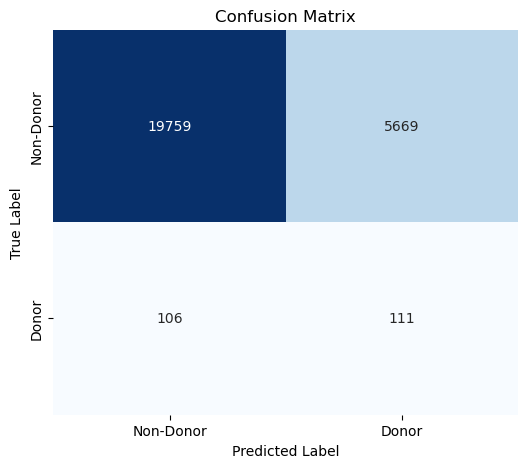

In [ ]:
# ==========================================
#        FINAL MODEL CONFIGURATION
# ==========================================

# 1. Define Strategy
feature_method = "Full Set"
model_type = "CatBoost"

print(f"--- STRATEGY SUMMARY ---")
print(f"Feature Selection: {feature_method}")
print(f"Model Algorithm:   {model_type}")

# 2. Perform Feature Selection
# We re-run the selection to ensure we have the exact list
final_features = X_train.columns.tolist()

print(f"\n--- FINAL SET OF {len(final_features)} FEATURES ---")
print(final_features)

# 3. Define the Champion Model
cb_optimized = CatBoostClassifier(
    iterations=100,
    depth=4,
    learning_rate=0.1,
    l2_leaf_reg=3,
    scale_pos_weight=35.70947368421053,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=0,
    random_seed=42,
    allow_writing_files=False
)

print(f"\n--- MODEL PARAMETERS ---")
print(f"Scale Pos Weight: 35.71")
print(f"Learning Rate:    0.1")
print(f"Depth:            4")
print(f"Iterations:       100")
print(f"L2 Leaf Reg:      3")

# 4. Train & Evaluate
print(f"\n--- TRAINING & RESULTS ---")
cb_optimized.fit(X_train[final_features], y_train)

# Predict on Test Set
y_probs_final = cb_optimized.predict_proba(X_test[final_features])[:, 1]
y_preds_final = cb_optimized.predict(X_test[final_features])

# Calculate Scores
final_auc = roc_auc_score(y_test, y_probs_final)
final_acc = accuracy_score(y_test, y_preds_final)

print("-" * 30)
print(f"FINAL TEST AUC:      {final_auc:.2f}")
print(f"FINAL TEST ACCURACY: {final_acc:.2%}")
print("-" * 30)

# --- DETAILED METRICS ---
print("\n--- CLASSIFICATION REPORT ---")
# We specify target_names to make it easy to read
print(classification_report(y_test, y_preds_final, target_names=['Non-Donor (0)', 'Donor (1)']))

# --- CONFUSION MATRIX VISUALIZATION ---
cm = confusion_matrix(y_test, y_preds_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Donor', 'Donor'],
            yticklabels=['Non-Donor', 'Donor'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### 📈 **9. Model Evaluation: Lift & Cumulative Gains**
To validate the model's ability to **rank** donors effectively, we inspect two key marketing charts:
1.  **Cumulative Gains:** Shows what % of all donors we capture if we contact the top X% of the list. Steeper curves are better.
2.  **Lift Curve:** Shows how much better the model is compared to random selection. A Lift of 3.0 at the 10% mark means the top decile is **3x more likely** to donate than average.

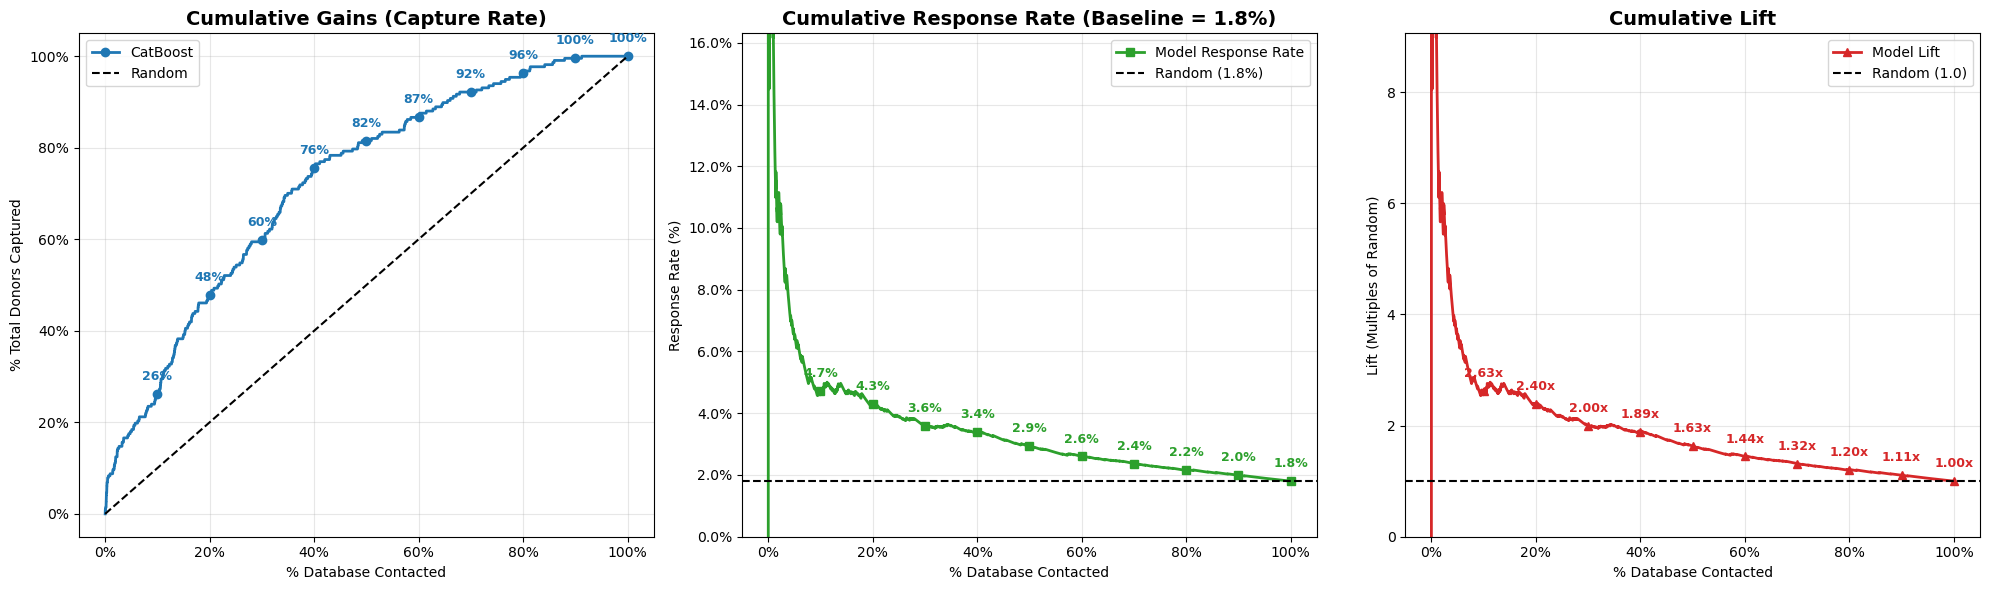


      DETAILED PERFORMANCE SUMMARY (5% Intervals)
% Contacted % Captured Response Rate Lift
         5%      18.0%         6.47% 3.60
        10%      26.3%         4.73% 2.63
        15%      39.2%         4.70% 2.61
        20%      47.9%         4.31% 2.40
        25%      53.9%         3.88% 2.16
        30%      59.9%         3.59% 2.00
        35%      70.0%         3.60% 2.00
        40%      75.6%         3.40% 1.89
        45%      78.3%         3.13% 1.74
        50%      81.6%         2.94% 1.63
        55%      83.4%         2.73% 1.52
        60%      86.6%         2.60% 1.44
        65%      89.9%         2.49% 1.38
        70%      92.2%         2.37% 1.32
        75%      94.0%         2.26% 1.25
        80%      96.3%         2.17% 1.20
        85%      98.2%         2.08% 1.15
        90%      99.5%         1.99% 1.11
        95%     100.0%         1.89% 1.05
       100%     100.0%         1.80% 1.00



In [68]:
h.plot_model_performance(y_test, y_probs_final, target_baseline=1.8)

### 🚀 **10. Final Prediction & Submission Generation**
We apply our trained **Champion Model** (`cb_optimized`) to the **Scoring Dataset** (Campaign 7362).
* **Goal:** Calculate the probability of donation for each donor in the 2020 campaign list.
* **Output:** A CSV file sorted by probability, ready for submission.

In [ ]:
# --- GENERATE PREDICTIONS FOR SCORE DATASET ---

print("Generating predictions for Campaign 7362 (Score dataset)...")

# 1. Predict Probabilities
# We use the same features used during training
# Note: CatBoost handles the dataframe directly
score_predictions_proba = cb_optimized.predict_proba(score[final_features])[:, 1]

# 2. Create Submission DataFrame
# We use the donorID from the score dataframe or the original selection dataframe
# Assuming 'score' still has the 'donorID' column (it should from align_datasets)
submission = pd.DataFrame({
    'donorID': score['donorID'], 
    'proba_donation': score_predictions_proba
})

# 3. Sort by Probability (Highest First)
submission = submission.sort_values(by='proba_donation', ascending=False)

# 4. Export to CSV
submission.to_csv(r'../date/Scored_Campaign_7362_Final.csv', index=False)

print("\n" + "="*40)
print(f"✅ SUCCESS! Predictions saved to: {'../date/Scored_Campaign_7362_Final.csv'}")
print("="*40)
print(f"Total Rows: {len(submission)}")
print(f"Top 5 Candidates:\n")
print(submission.head())

# Optional: Check distribution
print("\nPrediction Stats:")
print(submission['proba_donation'].describe())

Generating predictions for Campaign 7362 (Score dataset)...

✅ SUCCESS! Predictions saved to: Scored_Campaign_7362_Final.csv
Total Rows: 26511
Top 5 Candidates:

       donorID  proba_donation
24231  D104072        0.913732
26301  D126373        0.896905
16872  D142020        0.894575
5073   D116368        0.893450
6233   D100267        0.869447

Prediction Stats:
count    26511.000000
mean         0.377957
std          0.167128
min          0.028076
25%          0.224741
50%          0.323291
75%          0.528688
max          0.913732
Name: proba_donation, dtype: float64


### 🕵️ **11. Profiling the Target Audience (Top 20%)**
To provide actionable business intelligence, we analyze the profile of the **Top 20%** of candidates identified by our model. These are the donors we are recommending for contact.

**Key Objectives:**
1.  **Validation:** Ensure the selected donors make sense (e.g., they should historically have higher frequency or recency).
2.  **Marketing Strategy:** Understand their demographics (Age, Region, Gender) to tailor the campaign message.
3.  **Behavioral Insight:** Check if our model prioritized specific traits like "Spontaneous Giving" or "Consistency."

In [70]:
# extracting top 20% of potential donors:
top_20_count = int(len(submission) * 0.20)
top20 = submission.head(top_20_count)

# extracting the donor IDs:
top20_ids = top20["donorID"]
top20_features = score_df[score_df["donorID"].isin(top20_ids)]

# Changing some column types:
categorical_int_cols = ["isGenderMissing", "is_independent_donor", "is_top_20_percent", "is_top_10_percent", "frequency_independent", "total_amount_bin", "avg_amount_bin"]
top20_features[categorical_int_cols] = top20_features[categorical_int_cols].astype("category")

h.summarize_features(top20_features.drop({"donorID"}, axis=1), 43)

📌 Column: gender
Type: object
Missing values: 0
Unique values: 2

Value counts:
gender
F    4924
M     378
Name: count, dtype: int64


📌 Column: province
Type: object
Missing values: 0
Unique values: 11

Value counts:
province
West Flanders      1458
Flemish Brabant    1184
Antwerp             995
East Flanders       842
Limburg             342
Liege               167
Hainaut             121
Namur                67
Brussels             67
Luxembourg           47
Walloon Brabant      12
Name: count, dtype: int64


📌 Column: region
Type: object
Missing values: 0
Unique values: 3

Value counts:
region
Flanders    4821
Wallonia     414
Brussels      67
Name: count, dtype: int64


📌 Column: language
Type: object
Missing values: 0
Unique values: 2

Value counts:
language
NL    4810
FR     492
Name: count, dtype: int64


📌 Column: isGenderMissing
Type: category
Missing values: 0
Unique values: 2

Value counts:
isGenderMissing
0    5301
1       1
Name: count, dtype: int64


📌 Column: age
Type: